In [20]:
import pandas as pd
df = pd.read_csv('/workspaces/SML/SML /train_v9rqX0R.csv')
df.head()
df.shape

(8523, 12)

In [21]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [22]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [23]:
#impute item_weight with mean
mean = df['Item_Weight'].mean()
df['Item_Weight'] = df['Item_Weight'].fillna(mean)

#impute Outlet_size with mode
mode = df['Outlet_Size'].mode()[0]
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode)

In [24]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [25]:
df.drop(['Item_Identifier','Outlet_Identifier'],axis=1,inplace=True)
df = pd.get_dummies(df)

In [26]:
df.shape

(8523, 36)

In [27]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df,test_size=0.3)
x_train = train.drop('Item_Outlet_Sales',axis=1)
y_train = train['Item_Outlet_Sales']
x_test = test.drop('Item_Outlet_Sales',axis=1)
y_test = test['Item_Outlet_Sales']

In [28]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

x_train_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train_scaled)

x_test_scaled = scaler.fit_transform(x_test)
y_test_scaled = pd.DataFrame(x_test_scaled)

In [29]:
y_test_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2557 entries, 0 to 2556
Data columns (total 35 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       2557 non-null   float64
 1   1       2557 non-null   float64
 2   2       2557 non-null   float64
 3   3       2557 non-null   float64
 4   4       2557 non-null   float64
 5   5       2557 non-null   float64
 6   6       2557 non-null   float64
 7   7       2557 non-null   float64
 8   8       2557 non-null   float64
 9   9       2557 non-null   float64
 10  10      2557 non-null   float64
 11  11      2557 non-null   float64
 12  12      2557 non-null   float64
 13  13      2557 non-null   float64
 14  14      2557 non-null   float64
 15  15      2557 non-null   float64
 16  16      2557 non-null   float64
 17  17      2557 non-null   float64
 18  18      2557 non-null   float64
 19  19      2557 non-null   float64
 20  20      2557 non-null   float64
 21  21      2557 non-null   float64
 22  

In [30]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
%matplotlib inline

In [31]:
rmse_val = []
k_list = []
for K in range(50):
    K = K+1
    model = neighbors.KNeighborsRegressor(n_neighbors=K)

    model.fit(x_train,y_train)
    pred = model.predict(x_test)
    error = sqrt(mean_squared_error(y_test,pred))
    rmse_val.append(error)
    k_list.append(K)

    print("RMSE value for k =",K,"is",error)


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


RMSE value for k = 1 is 3796.955850037504
RMSE value for k = 2 is 3128.8090214565827
RMSE value for k = 3 is 2964.083934073467


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


RMSE value for k = 4 is 2739.7708356021367
RMSE value for k = 5 is 2629.3993798606375
RMSE value for k = 6 is 2524.427945936069


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


...

RMSE value for k = 45 is 2140.0231656125407
RMSE value for k = 46 is 2130.843091475797


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


RMSE value for k = 47 is 2121.722683592768
RMSE value for k = 48 is 2118.8402549756115
RMSE value for k = 49 is 2121.2289321039534


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


RMSE value for k = 50 is 2122.8050991325767


In [15]:
best_rmse_score= min(rmse_val)
best_k = k_list[rmse_val.index(best_rmse_score)]
print("Optimum K value=",best_k,"with Score=",best_rmse_score)

Optimum K value= 18 with Score= 2152.091420759881


<Axes: >

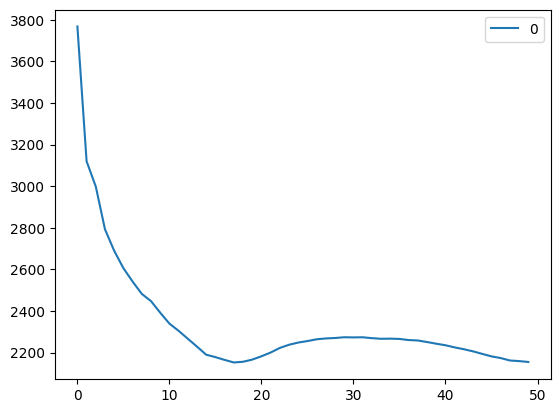

In [16]:
#ploting  the rmse values against k values
curve = pd.DataFrame(rmse_val) #elbow curve
curve.plot()